# Corigami Plan A Dip3D benchmark with merge

Reproduce the Dip3D insulation and SCC benchmark plots from
`corigami_predict_benchmark_dip3d.ipynb` for `all`, `mat`, `pat`, and
`merge`. All four groups are restricted to the same prediction regions.

In [1]:
options(stringsAsFactors = FALSE)

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(reshape2)
  library(data.table)
  library(reticulate)
  library(imager)
  library(pbmcapply)
  library(hicrep)
  library(qs)
  library(ggplot2)
  library(ggpointdensity)
  library(cowplot)
  library(scales)
  library(Cairo)
})

CairoFonts(
  regular = "sans:style=Regular",
  bold = "sans:style=Bold",
  italic = "sans:style=Italic",
  bolditalic = "sans:style=Bold Italic,BoldItalic",
  symbol = "Symbol",
  usePUA = TRUE
)

paths <- list(
  output_dir = "../results/CD_Revision2",
  bins = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/project/scHic/ref/GM12878/bam/GM12878_merged_10k_bins.gz",
  hic = "GM12878_dip3d_chr_mtx.qs",
  snp_density = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/database/GM12878/GM12878/GM12878_2M_10k_snp_density_summary.txt",
  snp_count = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/database/GM12878/GM12878/GM12878_10k_snp_counts_summary_sorted.bedGraph",
  source_ins = "./corigami/dip3d_insulation_corr_h5v1_all.qs",
  source_scc = "./corigami/dip3d_SSC_correlation_all.qs"
)

prediction_dirs <- c(
  all = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/software/corigami/predict/GM12878/prediction/npy",
  merge = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/software/corigami/predict/GM12878_merge/prediction/npy",
  mat = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/software/corigami/predict/GM12878_mat/prediction/npy",
  pat = "/gpfs1/tangfuchou_pkuhpc/tangfuchou_test/lujiansen/software/corigami/predict/GM12878_pat/prediction/npy"
)

hap_levels <- c("all", "merge", "mat", "pat")
reference_hap <- c(all = "all", merge = "all", mat = "mat", pat = "pat")
recompute <- FALSE
cores <- 20L
raw_smoke_mode <- identical(Sys.getenv("DIP3D_SMOKE"), "1")
cache_smoke_mode <- identical(Sys.getenv("DIP3D_CACHE_SMOKE"), "1")
smoke_mode <- raw_smoke_mode || cache_smoke_mode
if (smoke_mode) {
  paths$output_dir <- file.path(tempdir(), "dip3d_planA_merge_smoke")
  recompute <- raw_smoke_mode
  cores <- 1L
}

required_paths <- c(
  unname(prediction_dirs), paths$bins, paths$hic,
  paths$snp_density, paths$snp_count
)
missing_paths <- required_paths[!file.exists(required_paths)]
if (length(missing_paths) > 0) {
  stop("Missing required inputs: ", paste(missing_paths, collapse = ", "))
}
dir.create(paths$output_dir, recursive = TRUE, showWarnings = FALSE)

## Discover the common Plan A prediction regions

In [2]:
prediction_files <- lapply(prediction_dirs, function(path) {
  files <- list.files(path, pattern = "\\.npy$", full.names = TRUE)
  stats::setNames(files, sub("\\.npy$", "", basename(files)))
})

file_counts <- tibble(
  hap = factor(names(prediction_files), levels = hap_levels),
  n_files = lengths(prediction_files)
)
file_counts

common_regions <- Reduce(intersect, lapply(prediction_files, names))
common_regions <- sort(common_regions)
if (length(common_regions) == 0) {
  stop("No common prediction regions found")
}

stopifnot(all(vapply(prediction_files, function(files) {
  all(common_regions %in% names(files))
}, logical(1))))

tibble(n_common_regions = length(common_regions))

hap,n_files
<fct>,<int>
all,5455
merge,5000
mat,5459
pat,5455


n_common_regions
<int>
5000


## Load Dip3D reference matrices and SNP annotations

In [3]:
bins <- read.table(paths$bins)
colnames(bins) <- c("chr", "start", "end")
bins$idx <- 0:(nrow(bins) - 1L)

hic_df <- qread(paths$hic)

snp_sum_sw <- read.table(paths$snp_density, header = TRUE) %>%
  mutate(
    pos = paste(chrom, start, sep = "_"),
    rank = row_number(),
    valid = pos %in% common_regions
  )

snp_count <- read.table(paths$snp_count)
colnames(snp_count) <- c("chr", "start", "end", "snp")

common_region_df <- snp_sum_sw %>% filter(valid)
if (nrow(common_region_df) == 0) {
  stop("No common prediction regions are represented in the SNP summary")
}
if (smoke_mode) {
  common_region_df <- common_region_df %>% slice_head(n = 1)
}

source_scc_index <- if (file.exists(paths$source_scc)) {
  qread(paths$source_scc)
} else {
  NULL
}
source_ranks <- if (is.null(source_scc_index)) {
  integer()
} else {
  sort(unique(as.integer(source_scc_index$rank)))
}
source_region_df <- snp_sum_sw %>% filter(rank %in% source_ranks)

tibble(
  n_snp_regions = nrow(snp_sum_sw),
  n_source_cached_regions = nrow(source_region_df),
  n_four_way_valid_regions = nrow(common_region_df)
)

n_snp_regions,n_source_cached_regions,n_four_way_valid_regions
<int>,<int>,<int>
6004,4983,5000


## Matrix helpers

In [4]:
df2mtx <- function(df, start_id, end_id, val_col) {
  df %>%
    dplyr::filter(
      .data$id1 %in% start_id:end_id,
      .data$id2 %in% start_id:end_id
    ) %>%
    dplyr::mutate(
      id1 = factor(.data$id1, levels = start_id:end_id),
      id2 = factor(.data$id2, levels = start_id:end_id)
    ) %>%
    dplyr::group_by(.data$id1, .data$id2) %>%
    dplyr::summarise(
      "{val_col}" := mean(.data[[val_col]], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    reshape2::dcast(id1 ~ id2, value.var = val_col, drop = FALSE) %>%
    tibble::column_to_rownames("id1") %>%
    as.matrix()
}

tri_to_full <- function(mtx) {
  full_mtx <- mtx
  full_mtx[lower.tri(full_mtx)] <- t(mtx)[lower.tri(t(mtx))]
  full_mtx
}

plot_alelic_map <- function(
    chr, start, val_col = "counts", width = 210, plot = FALSE,
    verbose = FALSE, df = hic_df) {
  start_id <- bins[bins$chr == chr & bins$start == as.integer(start), ]$idx
  if (length(start_id) != 1L) {
    stop("Expected one reference start bin for ", chr, "_", start)
  }
  end_id <- start_id + width - 1L

  if (verbose) {
    message("start id: ", start_id)
    message("end id: ", end_id)
  }

  pmtx <- df2mtx(df[[paste0("HP1_", chr)]], start_id, end_id, val_col) %>%
    tri_to_full()
  mmtx <- df2mtx(df[[paste0("HP2_", chr)]], start_id, end_id, val_col) %>%
    tri_to_full()
  amtx <- df2mtx(df[[paste0("all_", chr)]], start_id, end_id, val_col) %>%
    tri_to_full()

  pmtx[is.na(pmtx)] <- 0
  mmtx[is.na(mmtx)] <- 0
  amtx[is.na(amtx)] <- 0

  if (plot) {
    stop("Plotting reference matrices is outside this benchmark notebook")
  }
  list(data = list(pat = pmtx, mat = mmtx, all = amtx))
}

loadnpy <- function(file) {
  np <- reticulate::import("numpy")
  np$load(file)
}

resize_mtx <- function(mtx, size = 210) {
  suppressMessages(im <- as.cimg(mtx))
  suppressMessages(resized_im <- imager::resize(
    im,
    size_x = size,
    size_y = size,
    interpolation = 3
  ))
  suppressMessages(as.matrix(resized_im))
}

load_prediction <- function(hap, region_id) {
  file <- prediction_files[[hap]][[region_id]]
  if (is.null(file) || !file.exists(file)) {
    stop("Missing prediction for ", hap, " ", region_id)
  }
  resize_mtx(loadnpy(file))
}

get_snp_vector <- function(chr, start, width = 210L, resolution = 10000L) {
  bin_starts <- as.integer(start) + (0:(width - 1L)) * resolution
  chr_counts <- snp_count %>% filter(.data$chr == .env$chr)
  idx <- match(bin_starts, chr_counts$start)
  if (anyNA(idx)) {
    stop("Missing SNP-count bins for ", chr, "_", start)
  }
  chr_counts$snp[idx]
}

## Insulation correlation

In [5]:
calc_diag_sum_offset <- function(mtx, w, s = 1) {
  df <- lapply(1:(nrow(mtx) - 1), function(n) {
    sub_mtx <- mtx[
      (n + 1):min((n + w), nrow(mtx)),
      (n - 1):max((n - w), 1)
    ]
    S <- sum(sub_mtx, na.rm = TRUE)
    C <- sum(!is.na(sub_mtx))
    c(n, S, C, S / C)
  }) %>%
    do.call(rbind, .) %>%
    as.data.frame() %>%
    `colnames<-`(c("idx", "sum", "count", "avg"))
  avg <- mean(df$avg, na.rm = TRUE)
  df$norm <- log2(df$avg / avg)
  df
}

calc_ins_cor <- function(
    chr, start, haps = hap_levels, w = 20, h = 5, min_snp = 1,
    cor_method = "pearson") {
  region_id <- paste(chr, as.integer(start), sep = "_")
  ref <- plot_alelic_map(chr, start, plot = FALSE)$data
  snp_vector <- get_snp_vector(chr, start)

  bind_rows(lapply(haps, function(hap) {
    pred_ins <- calc_diag_sum_offset(load_prediction(hap, region_id), w, 1)
    ref_h <- if (hap %in% c("all", "merge")) 1 else h
    ref_ins <- calc_diag_sum_offset(
      log2(hicrep::fast.mean.filter(
        ref[[reference_hap[[hap]]]], h = ref_h
      ) + 1),
      w,
      1
    )

    keep <- snp_vector[pred_ins$idx] >= min_snp
    ref_value <- scales::rescale(ref_ins$norm[keep], to = c(0, 1))
    pred_value <- scales::rescale(pred_ins$norm[keep], to = c(0, 1))
    value <- suppressWarnings(cor(
      ref_value,
      pred_value,
      use = "pairwise.complete.obs",
      method = cor_method
    ))

    tibble(
      region_id = region_id,
      chrom = chr,
      start = as.integer(start),
      hap = hap,
      cor = value
    )
  }))
}

calc_top_ins_cor <- function(
    df, haps = hap_levels, h = 5, w = 20, min_snp = 1,
    cores = 20L, cor_method = "pearson") {
  pbmclapply(seq_len(nrow(df)), function(i) {
    suppressMessages(calc_ins_cor(
      df$chrom[[i]],
      df$start[[i]],
      haps = haps,
      w = w,
      h = h,
      min_snp = min_snp,
      cor_method = cor_method
    )) %>%
      mutate(
        mean_snp = df$mean_value[[i]],
        rank = df$rank[[i]],
        h = h,
        min_snp = min_snp
      )
  }, mc.cores = cores, ignore.interactive = TRUE) %>%
    bind_rows()
}

ins_cache <- file.path(
  paths$output_dir,
  "dip3d_insulation_corr_h5v1_all_planA_merge.qs"
)

if (!recompute && file.exists(ins_cache)) {
  ins_res_all <- qread(ins_cache)
} else if (
    !recompute && file.exists(paths$source_ins) &&
      !is.null(source_scc_index)) {
  source_ins <- qread(paths$source_ins)
  if (nrow(source_ins) != nrow(source_region_df) * 3L) {
    stop("Source insulation cache does not match source SCC region ranks")
  }

  source_ins$region_id <- rep(source_region_df$pos, each = 3L)
  source_ins$rank <- rep(source_region_df$rank, each = 3L)
  source_ins <- source_ins %>%
    filter(.data$region_id %in% common_region_df$pos) %>%
    left_join(
      common_region_df %>%
        transmute(
          region_id = pos,
          chrom,
          start,
          rank_ref = rank,
          mean_snp_ref = mean_value
        ),
      by = "region_id"
    ) %>%
    transmute(
      region_id,
      chrom,
      start,
      hap = as.character(hap),
      cor = as.numeric(cor),
      mean_snp = mean_snp_ref,
      rank = rank_ref,
      h = as.integer(h),
      min_snp = as.integer(min_snp)
    )

  missing_source_regions <- common_region_df %>%
    filter(!.data$pos %in% source_ins$region_id)
  missing_source_ins <- if (nrow(missing_source_regions) == 0) {
    source_ins[0, ]
  } else {
    calc_top_ins_cor(
      missing_source_regions,
      haps = c("all", "mat", "pat"),
      h = 5,
      min_snp = 1,
      cores = cores
    )
  }
  merge_ins <- calc_top_ins_cor(
    common_region_df,
    haps = "merge",
    h = 5,
    min_snp = 1,
    cores = cores
  )
  ins_res_all <- bind_rows(source_ins, missing_source_ins, merge_ins)
  qsave(ins_res_all, ins_cache)
} else {
  ins_res_all <- calc_top_ins_cor(
    common_region_df,
    haps = hap_levels,
    h = 5,
    min_snp = 1,
    cores = cores
  )
  qsave(ins_res_all, ins_cache)
}

ins_res_all <- ins_res_all %>%
  mutate(hap = factor(as.character(hap), levels = hap_levels)) %>%
  arrange(rank, hap)

ins_region_counts <- ins_res_all %>% count(region_id)
stopifnot(
  nrow(ins_region_counts) == nrow(common_region_df),
  all(ins_region_counts$n == 4L),
  all(hap_levels %in% as.character(unique(ins_res_all$hap)))
)

top100_regions <- common_region_df %>%
  slice_head(n = 100) %>%
  pull(pos)
ins_res_top100 <- ins_res_all %>% filter(region_id %in% top100_regions)
stopifnot(n_distinct(ins_res_top100$region_id) == min(100L, nrow(common_region_df)))

### Insulation summaries

In [6]:
ins_summary_all <- ins_res_all %>%
  group_by(hap) %>%
  summarise(
    mean = mean(cor, na.rm = TRUE),
    median = median(cor, na.rm = TRUE),
    .groups = "drop"
  )
ins_summary_all

hap,mean,median
<fct>,<dbl>,<dbl>
all,0.8378261,0.8703849
merge,0.6694635,0.7055754
mat,0.5377674,0.5710973
pat,0.5439761,0.5747762


In [7]:
ins_summary_top100 <- ins_res_top100 %>%
  group_by(hap) %>%
  summarise(
    mean = mean(cor, na.rm = TRUE),
    median = median(cor, na.rm = TRUE),
    .groups = "drop"
  )
ins_summary_top100

hap,mean,median
<fct>,<dbl>,<dbl>
all,0.8375881,0.8652841
merge,0.6507829,0.7047809
mat,0.5910593,0.6229630
pat,0.6055874,0.6371221


## Stratified correlation coefficient (SCC)

In [8]:
get.scc2 <- function(mat1, mat2, resol, h, lbr = 0, ubr = 5e+06) {
  if (h == 0) {
    smt_R1 <- mat1
    smt_R2 <- mat2
  } else {
    smt_R1 <- hicrep:::fastMeanFilter(as.matrix(mat1), h)
    rm(mat1)
    smt_R2 <- hicrep:::fastMeanFilter(as.matrix(mat2), h)
    rm(mat2)
  }

  lb <- floor(lbr / resol)
  ub <- floor(ubr / resol)

  est.scc <- function(dist) {
    ffd1 <- ffd2 <- NULL
    for (i in 1:(ncol(smt_R1) - dist)) {
      ffd1 <- c(ffd1, smt_R1[i + dist, i])
      ffd2 <- c(ffd2, smt_R2[i + dist, i])
      filt <- which(ffd1 == 0 & ffd2 == 0)
      if (length(filt) == 0) {
        ffd <- cbind(ffd1, ffd2)
      } else {
        ffd <- cbind(ffd1[-filt], ffd2[-filt])
      }
    }

    if (nrow(ffd) != 0) {
      n <- nrow(ffd)
      nd <- hicrep:::vstran(ffd)
      if (length(unique(ffd[, 1])) != 1 && length(unique(ffd[, 2])) != 1) {
        corr <- cor(ffd[, 1], ffd[, 2], use = "pairwise.complete.obs")
        wei <- sqrt(var(nd[, 1]) * var(nd[, 2])) * n
      } else {
        corr <- NA_real_
        wei <- NA_real_
      }
    } else {
      corr <- NA_real_
      wei <- NA_real_
    }
    list(corr = corr, wei = wei)
  }

  st <- sapply(seq(lb, ub), est.scc)
  corr0 <- unlist(st[1, ])
  wei0 <- unlist(st[2, ])
  keep <- !is.na(corr0) & !is.na(wei0)
  corr <- corr0[keep]
  wei <- wei0[keep]
  scc <- corr %*% wei / sum(wei)
  std <- sqrt(sum(wei^2 * var(corr)) / (sum(wei))^2)
  list(corr = corr, wei = wei, scc = scc, std = std)
}

calc_scc <- function(
    chr, start, haps = hap_levels, min_snp = 1, na_value = NA_real_, h = 5,
    lbr = 0, ubr = 1000000, resol = 10000) {
  region_id <- paste(chr, as.integer(start), sep = "_")
  ref <- plot_alelic_map(chr, start, "counts")$data
  snp_vector <- get_snp_vector(chr, start)
  na_id <- which(snp_vector <= min_snp)

  stats::setNames(vapply(haps, function(hap) {
    pred <- hicrep:::fastMeanFilter(as.matrix(load_prediction(hap, region_id)), h = h)
    truth <- hicrep:::fastMeanFilter(
      as.matrix(ref[[reference_hap[[hap]]]]),
      h = h
    )

    pred[na_id, ] <- na_value
    pred[, na_id] <- na_value
    truth[na_id, ] <- na_value
    truth[, na_id] <- na_value

    as.numeric(get.scc2(
      pred,
      truth,
      h = 0,
      lbr = lbr,
      ubr = ubr,
      resol = resol
    )$scc)
  }, numeric(1)), haps)
}

calc_top_scc <- function(
    df, haps = hap_levels, h = 5, min_snp = 1, cores = 20L) {
  values <- pbmclapply(seq_len(nrow(df)), function(i) {
    value <- try(calc_scc(
      df$chrom[[i]],
      df$start[[i]],
      haps = haps,
      min_snp = min_snp,
      na_value = NA_real_,
      h = h
    ), silent = TRUE)

    if (inherits(value, "try-error") || any(!is.finite(value))) {
      value <- calc_scc(
        df$chrom[[i]],
        df$start[[i]],
        haps = haps,
        min_snp = min_snp,
        na_value = 0,
        h = h
      )
    }
    value
  }, mc.cores = cores, ignore.interactive = TRUE) %>%
    do.call(rbind, .)

  colnames(values) <- haps
  as.data.frame(values) %>%
    mutate(
      region_id = df$pos,
      chrom = df$chrom,
      start = df$start,
      mean_snp = df$mean_value,
      rank = df$rank,
      h = h,
      min_snp = min_snp
    ) %>%
    pivot_longer(all_of(haps), names_to = "hap", values_to = "cor")
}

scc_cache <- file.path(
  paths$output_dir,
  "dip3d_SSC_correlation_all_planA_merge.qs"
)

if (!recompute && file.exists(scc_cache)) {
  scc_res_all <- qread(scc_cache)
} else if (!recompute && file.exists(paths$source_scc)) {
  source_scc <- source_scc_index %>%
    transmute(
      rank = as.integer(rank),
      hap = as.character(variable),
      cor = as.numeric(value),
      h = as.integer(h),
      min_snp = as.integer(min_snp)
    ) %>%
    left_join(
      snp_sum_sw %>%
        transmute(
          rank,
          region_id = pos,
          chrom,
          start,
          mean_snp = mean_value
        ),
      by = "rank"
    ) %>%
    filter(
      .data$region_id %in% common_region_df$pos,
      .data$hap %in% c("all", "mat", "pat")
    )

  missing_source_regions <- common_region_df %>%
    filter(!.data$pos %in% source_scc$region_id)
  missing_source_scc <- if (nrow(missing_source_regions) == 0) {
    source_scc[0, ]
  } else {
    calc_top_scc(
      missing_source_regions,
      haps = c("all", "mat", "pat"),
      h = 5,
      min_snp = 1,
      cores = cores
    )
  }
  merge_scc <- calc_top_scc(
    common_region_df,
    haps = "merge",
    h = 5,
    min_snp = 1,
    cores = cores
  )
  scc_res_all <- bind_rows(source_scc, missing_source_scc, merge_scc)
  qsave(scc_res_all, scc_cache)
} else {
  scc_res_all <- calc_top_scc(
    common_region_df,
    haps = hap_levels,
    h = 5,
    min_snp = 1,
    cores = cores
  )
  qsave(scc_res_all, scc_cache)
}

scc_res_all <- scc_res_all %>%
  mutate(hap = factor(as.character(hap), levels = hap_levels)) %>%
  arrange(rank, hap)

scc_region_counts <- scc_res_all %>% count(region_id)
stopifnot(
  nrow(scc_region_counts) == nrow(common_region_df),
  all(scc_region_counts$n == 4L),
  all(hap_levels %in% as.character(unique(scc_res_all$hap)))
)

### SCC summary

In [9]:
scc_summary_all <- scc_res_all %>%
  group_by(hap) %>%
  summarise(
    mean = mean(cor, na.rm = TRUE),
    median = median(cor, na.rm = TRUE),
    .groups = "drop"
  )
scc_summary_all

hap,mean,median
<fct>,<dbl>,<dbl>
all,0.7510260,0.7908802
merge,0.5347535,0.5730646
mat,0.4122565,0.4401240
pat,0.4144714,0.4384244


## Original-style benchmark plots

Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


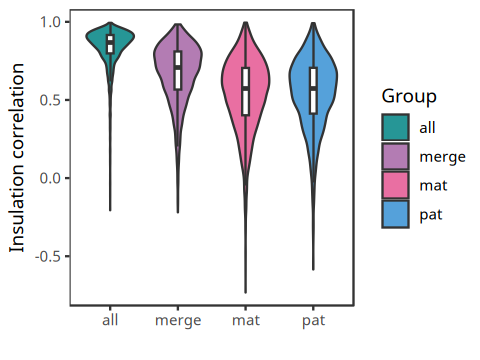

In [10]:
hap_colors <- c(
  all = "#269696",
  merge = "#b37cb3",
  mat = "#E96FA2",
  pat = "#55A1DA"
)

options(repr.plot.width = 4, repr.plot.height = 3)
p.1 <- ggplot(ins_res_all, aes(x = hap, y = cor)) +
  geom_violin(aes(fill = hap), scale = "width", width = 0.7) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  xlab("") +
  ylab("Insulation correlation") +
  scale_fill_manual("Group", values = hap_colors) +
  theme_bw() +
  theme(panel.grid = element_blank())
p.1

save_plot(
  file.path(paths$output_dir, "dip3d_insulation_corr_h5v1_all_violin.pdf"),
  p.1,
  base_height = 3,
  base_width = 4
)

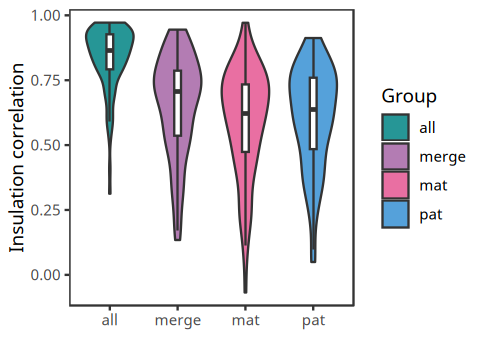

In [11]:
options(repr.plot.width = 4, repr.plot.height = 3)
p.2 <- ggplot(ins_res_top100, aes(x = hap, y = cor)) +
  geom_violin(aes(fill = hap), scale = "width", width = 0.7) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  xlab("") +
  ylab("Insulation correlation") +
  scale_fill_manual("Group", values = hap_colors) +
  theme_bw() +
  theme(panel.grid = element_blank())
p.2

save_plot(
  file.path(paths$output_dir, "dip3d_insulation_corr_h5v1_top100_violin.pdf"),
  p.2,
  base_height = 3,
  base_width = 4
)

Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_hex()`).”
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 38 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_hex()`).”


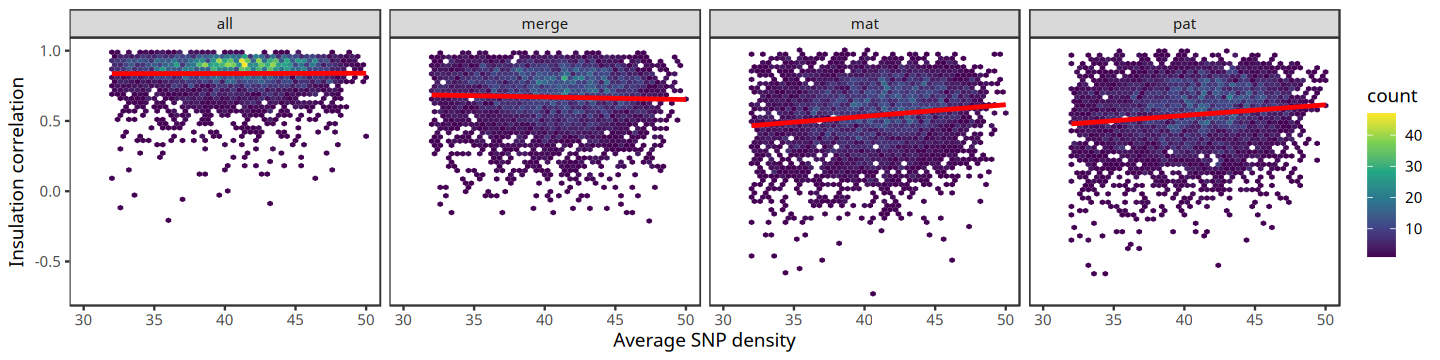

In [12]:
options(repr.plot.width = 12, repr.plot.height = 3)
p.3 <- ggplot(ins_res_all, aes(x = mean_snp, y = cor)) +
  geom_hex(bins = 50) +
  geom_smooth(method = "lm", aes(group = hap), color = "red") +
  xlim(30, 50) +
  facet_wrap(vars(hap), nrow = 1) +
  scale_fill_viridis_c() +
  theme_bw() +
  xlab("Average SNP density") +
  ylab("Insulation correlation") +
  theme(panel.grid = element_blank())
p.3

save_plot(
  file.path(paths$output_dir, "dip3d_insulation_corr_vs_mean_snp.pdf"),
  p.3,
  base_height = 3,
  base_width = 12
)

In [13]:
ins_snp_pearson <- ins_res_all %>%
  filter(
    between(.data$mean_snp, 30, 50),
    is.finite(.data$mean_snp),
    is.finite(.data$cor)
  ) %>%
  group_by(hap) %>%
  summarise(
    n = n(),
    pearson_r = cor(.data$mean_snp, .data$cor, method = "pearson"),
    .groups = "drop"
  )

ins_snp_pearson

hap,n,pearson_r
<fct>,<int>,<dbl>
all,4993,0.005452878
merge,4991,-0.037070792
mat,4988,0.139539412
pat,4990,0.129257640


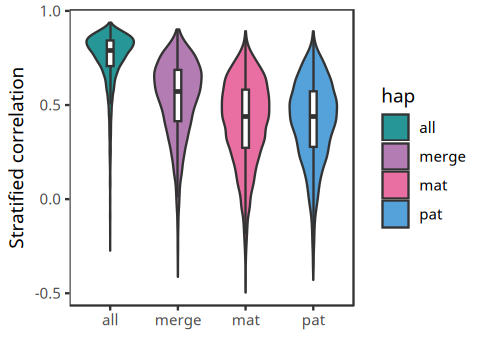

In [14]:
options(repr.plot.width = 4, repr.plot.height = 3)
p.4 <- ggplot(scc_res_all, aes(x = hap, y = cor)) +
  geom_violin(aes(fill = hap), scale = "width", width = 0.7) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  xlab("") +
  ylab("Stratified correlation") +
  scale_fill_manual(values = hap_colors) +
  theme_bw() +
  theme(panel.grid = element_blank())
p.4

save_plot(
  file.path(paths$output_dir, "dip3d_SSC_correlation_all_violin.pdf"),
  p.4,
  base_width = 4,
  base_height = 3
)

## Output verification

In [15]:
expected_pdfs <- file.path(paths$output_dir, c(
  "dip3d_insulation_corr_vs_mean_snp.pdf",
  "dip3d_SSC_correlation_all_violin.pdf",
  "dip3d_insulation_corr_h5v1_all_violin.pdf",
  "dip3d_insulation_corr_h5v1_top100_violin.pdf"
))

stopifnot(
  nrow(ins_summary_all) == 4L,
  nrow(ins_summary_top100) == 4L,
  nrow(scc_summary_all) == 4L,
  all(file.exists(expected_pdfs)),
  all(file.info(expected_pdfs)$size > 0)
)

tibble(file = expected_pdfs, bytes = file.info(expected_pdfs)$size)

file,bytes
<chr>,<dbl>
../results/CD_Revision2/dip3d_insulation_corr_vs_mean_snp.pdf,88220
../results/CD_Revision2/dip3d_SSC_correlation_all_violin.pdf,24320
../results/CD_Revision2/dip3d_insulation_corr_h5v1_all_violin.pdf,24052
../results/CD_Revision2/dip3d_insulation_corr_h5v1_top100_violin.pdf,25119
